### Enlace al Repositorio en Github
https://github.com/aleLobo31/UC3M_ML_P2_G26-

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import euclidean, cdist
from scipy.optimize import linear_sum_assignment
from hdbscan import validity_index as dbcv_score


## Importamos los datos

In [3]:
df = pd.read_csv("../data/stars_data.csv")

## EDA (Exploratory Data Analysis)

El dataset con el que vamos a trabajar tiene las siguientes características:

+ Entradas: 240

+ Columnas: 6
    + 4 Variables Numéricas

    + 2 Variables Categóricas con carácter ordinal

+ No existen Missing Values

In [588]:
# Información elemental de nuestro dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB


In [589]:
# Comprobamos si hay valores nulos en alguna fila
df.isna().sum()

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

In [590]:
# Descriptivos de las variables numéricas
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [591]:
# Exploramos las categorías de las variables categóricas
for col in df.select_dtypes('object'):
    print(df[col].unique())
    print()
    print(df[col].value_counts())
    print()

['Red' 'Blue White' 'White' 'Yellowish White' 'Blue white'
 'Pale yellow orange' 'Blue' 'Blue-white' 'Whitish' 'yellow-white'
 'Orange' 'White-Yellow' 'white' 'yellowish' 'Yellowish' 'Orange-Red'
 'Blue-White']

Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
white                   3
Yellowish White         3
Orange                  2
Whitish                 2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64

['M' 'B' 'A' 'F' 'O' 'K' 'G']

Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64



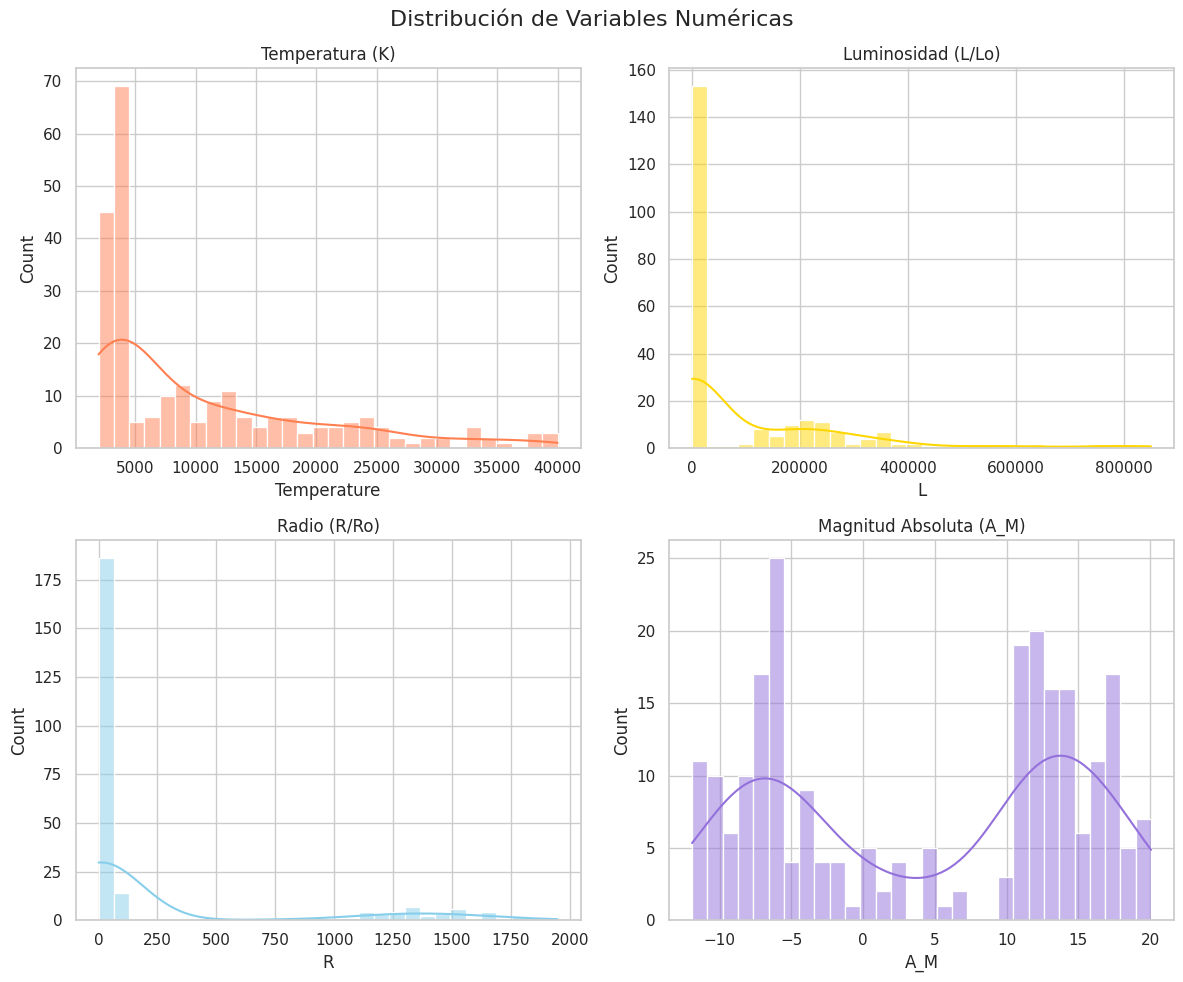

In [592]:
sns.set_theme(style="whitegrid")

# Histogramas para ver la distribución de las variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

sns.histplot(df['Temperature'], bins=30, kde=True, ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Temperatura (K)')

sns.histplot(df['L'], bins=30, kde=True, ax=axes[0, 1], color='gold')
axes[0, 1].set_title('Luminosidad (L/Lo)')

sns.histplot(df['R'], bins=30, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Radio (R/Ro)')

sns.histplot(df['A_M'], bins=30, kde=True, ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Magnitud Absoluta (A_M)')

plt.tight_layout()
plt.show()

Como podemos observar, para las 4 variables numéricas sus distribuciones son asimétricas y tinen unos outliers claros, especialmente en el caso de la Luminosidad y el Radio.

Además, la distribución de Magnitud Absoluta es bimodal, tiene una moda entorno a -7 y otra entorno a 12.
 
Esto nos da el insight de que será necesario hacer un escalado logarítmico para evitar que los outliers tengan tanto peso.

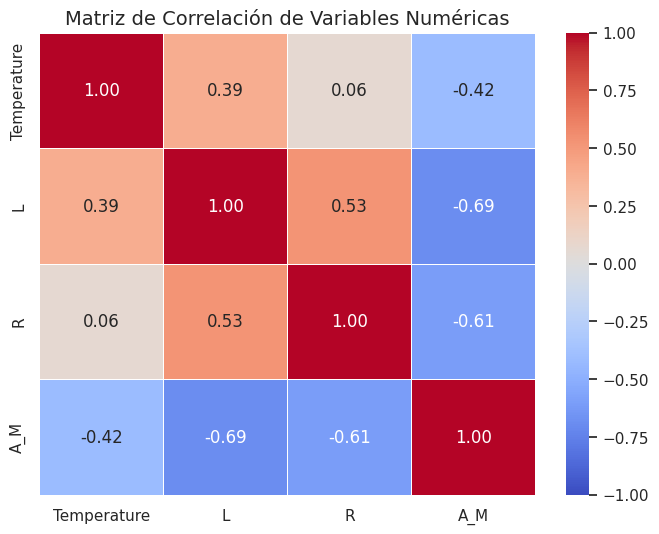

In [593]:
# Matriz de correlación para buscar relaciones lineales antes del PCA
plt.figure(figsize=(8, 6))

# Seleccionamos solo las columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14)
plt.show()

Podemos observar correlaciones bastante importantes, tanto positivas como negativas. Esto es importante ya que a la hora de realizar el PCA y reducir dimensiones, la correlación entre features juega un papel crucial.

Destacan especialmente las fuertes **correlaciones negativas** de la Magnitud Absoluta ($A\_M$) con la Luminosidad ($L$) y el Radio ($R$). Estas relaciones tienen una justificación astrofísica:

* **$A\_M$ vs $L$:** Ambas variables miden el brillo de la estrella, pero la magnitud absoluta utiliza una escala logarítmica invertida (a mayor luminosidad física, le corresponde un valor matemáticamente más bajo o negativo en magnitud).
  
* **$A\_M$ vs $R$:** Según la Ley de Stefan-Boltzmann, la luminosidad de una estrella crece con el cuadrado de su radio. Por tanto, las estrellas de mayor radio son mucho más luminosas, lo que a su vez empuja su magnitud absoluta hacia valores negativos.

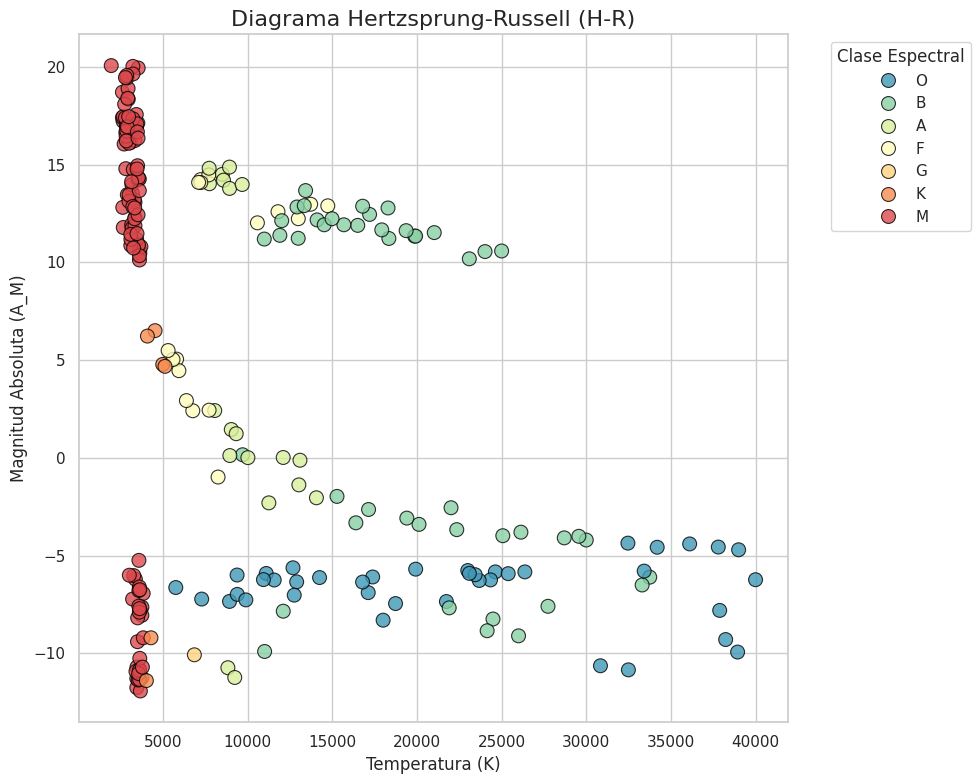

In [594]:
# Diagrama H-R: Temperatura vs Magnitud Absoluta
plt.figure(figsize=(10, 8))

# Ordenamos las clases espectrales para la leyenda
spectral_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']

sns.scatterplot(
    data=df, 
    x='Temperature', 
    y='A_M', 
    hue='Spectral_Class',
    hue_order=spectral_order,
    palette='Spectral_r',
    s=100, 
    alpha=0.8,
    edgecolor='black'
)

plt.title('Diagrama Hertzsprung-Russell (H-R)', fontsize=16)
plt.xlabel('Temperatura (K)', fontsize=12)
plt.ylabel('Magnitud Absoluta (A_M)', fontsize=12)
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Con este diagrama (Temperatura vs. Magnitud Absoluta) podemos observar que las estrellas del dataset presentan cierto agrupamiento natural inherente a sus características físicas. Visualmente, se distinguen clústeres algo definidos que separan a las estrellas en grupos diferenciados (como la secuencia principal, enanas o gigantes), coincidiendo con las clasificaciones astronómicas. 

Nuestros algoritmos de clustering deberán ser capaces de recuperar matemáticamente a partir de los componentes principales (PCA).

## Preprocessing

A continuación, vamos a realizar el preprocesado que va a consistir esencialmente en:

+ Convertir a variables ordinales las variables `color` y `spectral_class`.

+ Aplicar `StandardScaler` para poder usar PCA en el siguiente apartado.

In [4]:
# Función para limpiar los colores
def process_color(X: pd.DataFrame) -> pd.DataFrame:
    # Declaramos el diccionario de sustitución (también se podría hacer con un condicional)
    color_mapping = {
    'Red': 'Red',
    'Orange-Red': 'Orange', # Discutible Orange o Red
    'Orange': 'Orange',
    'Pale yellow orange': 'Orange', # Discutible si Yellow u Orange
    'Yellowish': 'Yellow',
    'yellowish': 'Yellow',
    'yellow-white': 'Yellow-White',
    'Yellowish White': 'Yellow-White',
    'White-Yellow': 'Yellow-White',
    'White': 'White',
    'white': 'White',
    'Whitish': 'White',
    'Blue White': 'Blue-White',
    'Blue white': 'Blue-White',
    'Blue-white': 'Blue-White',
    'Blue-White': 'Blue-White',
    'Blue': 'Blue'
    }

    # Hacemos una copia del Dataset
    X_out = X.copy()

    # Sustituimos el color usando el método replace
    X_out["Color"] = X_out["Color"].replace(color_mapping)

    return X_out

# Limpiamos la columna color porque tiene 17 categorías y muchas son redundantes
color_transformer = FunctionTransformer(process_color)


In [5]:
# Creamos dos listas con el ORDEN DESEADO.
color_order = ['Blue', 'Blue-White', 'White', 'Yellow-White', 'Yellow', 'Orange', 'Red']
spectral_class_order = ["O", "B", "A", "F", "G", "K", "M"] # O (frío) y M (caliente)

# Definimos las columnas sobre las que queremos aplicar el encoder
cat_cols = ['Color', 'Spectral_Class']

# Definimos preprocesado y escalado para las variables numéricas (muy importante el escalado logarítmico)
# Excluimos A_M ya que tiene valores negativos que pueden causar conflicto con el escalado logarítmico
num_cols = ['Temperature', 'L', 'R']

# Creamos el encoder que aplicaremos en la siguiente sección usando ColumnTransformer
# (Usamos OrdinalEncoder ya que el orden es importante)
encoder = ColumnTransformer(
    transformers=[
        ('num_encoder', FunctionTransformer(np.log1p), num_cols),
        ('cat_encoder', OrdinalEncoder(categories=[color_order, spectral_class_order]), cat_cols)
    ],
    remainder='passthrough' # Para seguir manteniendo las numéricas
)

## PCA

En esta sección, vamos a reducir la dimensionalidad de nuestro a dataset a dos dimensiones antes de aplicar algoritmos de clustering.

### Creación de Pipeline
Este pipeline es con el PCA sin especificar que sólo queremos las dos primeras componentes, ya que queremos obtener los gráficos de varianza explicada y sedimentación antes de sacar únicamente las dos componentes.

In [6]:
initial_pipe = Pipeline([
    ("color", color_transformer),
    ("encoder", encoder),
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

### Creación Conjunto Atributos

In [7]:
X = df.copy()

### Procesamiento del Pipeline

In [8]:
# Ajustar y transformar
X_reduced = initial_pipe.fit_transform(X)
pca = initial_pipe.named_steps['pca']

# Varianza explicada y acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Eigenvalues
eigenvalues = pca.explained_variance_

En esta gráfica podemos ver la varianza explicada por cada componente. Podemos observar que las que más explican son las dos primeras, el resto de componentes son residuales. Por lo que lo ideal será quedarse con las dos más relevantes (que es justo lo que pide el enunciado).

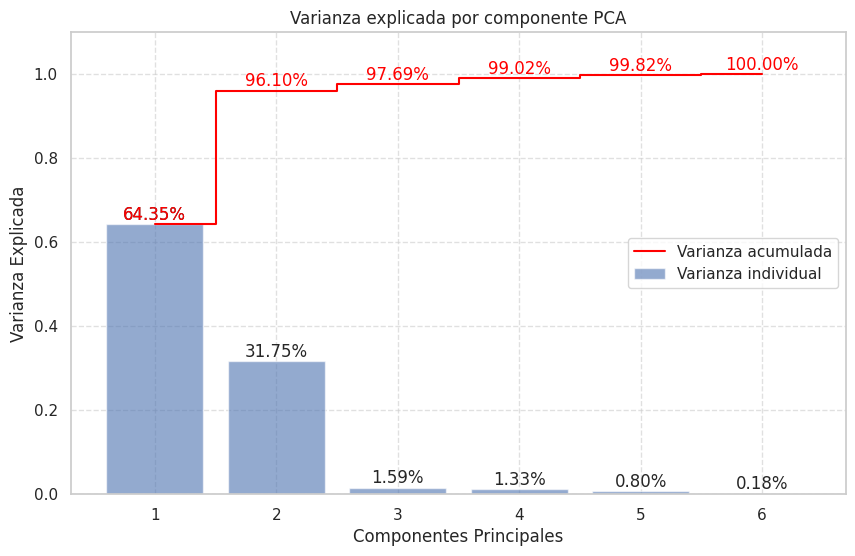

In [600]:
# Plot de Varianza Explicada y Acumulada
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Varianza acumulada', color='red')

# Añadir valores exactos
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
    plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza explicada por componente PCA')
plt.legend(loc='best')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)

En el siguiente gráfico de sedimentación podemos ver que el "codo" (la zona en la que la gráfica se aplana) es en el tercer componente, por lo que lo ideal tras hacer el PCA es quedarse con dos componentes, ya que el resto de componentes apenas aportan información relevante (justo lo que se pide en este ejercicio).

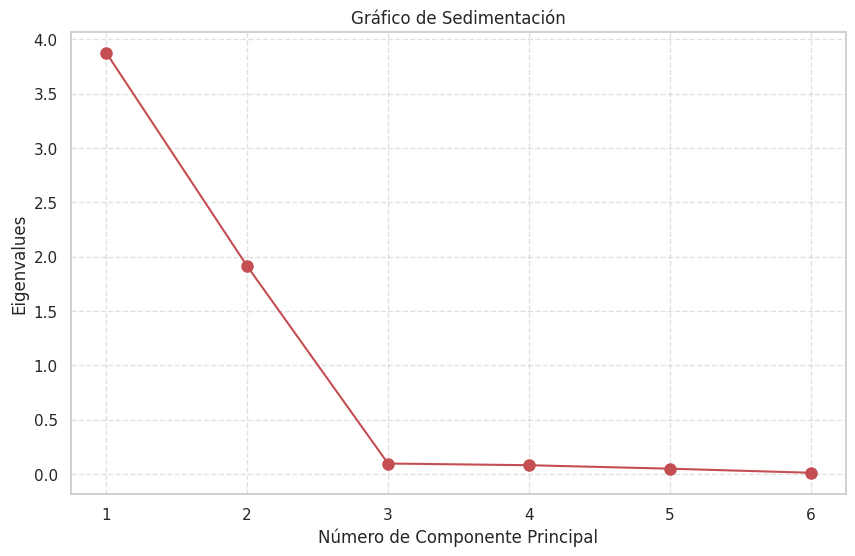

In [601]:
# Gráfico de sedimentación
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='r', markersize=8)

plt.title('Gráfico de Sedimentación')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Eigenvalues')
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True, linestyle='--', alpha=0.6)

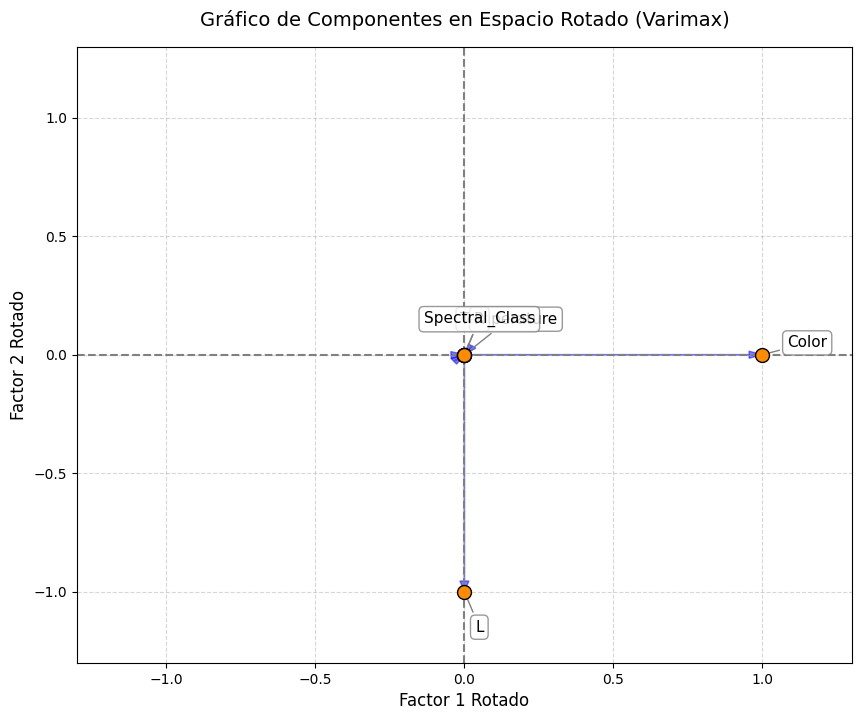

In [14]:
# Obtenemos los pesos (loadings). Están transpuestos para tener (n_features, n_components)
loadings = pca.components_.T

# Aplicamos la rotación Varimax (inline)
p, k = loadings.shape
R = np.eye(k)
for i in range(20):
    Lambda = np.dot(loadings, R)
    u, s, vh = np.linalg.svd(np.dot(loadings.T, np.asarray(Lambda)**3 - (1.0/p) * np.dot(Lambda, np.diag(np.diag(np.dot(Lambda.T, Lambda))))))
    R = np.dot(u, vh)

rotated_loadings = np.dot(loadings, R)

# Nombres de las características
# El ColumnTransformer preserva el orden: variables transformadas y el resto ("passthrough")
feature_names = num_cols + cat_cols

# Visualizamos los loadings rotados
plt.figure(figsize=(10, 8))
plt.scatter(rotated_loadings[:, 0], rotated_loadings[:, 1], color='darkorange', s=100, edgecolor='black', zorder=5)

for i, feature in enumerate(feature_names):
    x_val = rotated_loadings[i, 0]
    y_val = rotated_loadings[i, 1]
    
    # Desplazamiento radial y alternado para evitar apelotonamiento
    offset_x = 0.1 * np.sign(x_val) if abs(x_val) > 0.05 else 0.1
    offset_y = 0.1 * np.sign(y_val) if abs(y_val) > 0.05 else 0.1
    
    # Un pequeño factor extra dependiendo del índice para desempatar si caen cerca
    offset_y += 0.05 if i % 2 == 0 else -0.05
    offset_x += 0.05 if i % 3 == 0 else -0.05

    plt.annotate(feature, 
                 xy=(x_val, y_val), 
                 xytext=(x_val + offset_x, y_val + offset_y),
                 fontsize=11,
                 ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                 arrowprops=dict(arrowstyle="-", color='gray', lw=1))
                 
    plt.arrow(0, 0, x_val, y_val, color='blue', alpha=0.5, head_width=0.03, length_includes_head=True)

# Ejes de referencia
plt.axhline(0, color='grey', linestyle='--', linewidth=1.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=1.5)

plt.title('Gráfico de Componentes en Espacio Rotado (Varimax)', fontsize=14, pad=15)
plt.xlabel('Factor 1 Rotado', fontsize=12)
plt.ylabel('Factor 2 Rotado', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-1.3, 1.3)
plt.ylim(-1.3, 1.3)
plt.show()

### Interpretación de los Factores Rotados (Varimax)

Hemos aplicado una rotación Varimax para simplificar la lectura de los resultados, buscando que cada variable se relacione de forma clara con un solo eje. 

Al observar el gráfico extraemos dos conclusiones principales:

- El **Factor 1** (eje horizontal) se corresponde principalmente con el **Color** de la estrella.
  
- El **Factor 2** (eje vertical) está definido casi de forma exclusiva por la **Luminosidad** (L).

¿Por qué el resto de variables **no correlacionan** tan fuertemente con un único factor?

Esto sucede porque características como el *Radio*, la *Temperatura* o la *Magnitud Absoluta* no son dimensionalmente independientes en la astrofísica. Al ser propiedades "híbridas" que combinan información tanto del color como de la luminosidad, su varianza se reparte. Como resultado, el algoritmo no es capaz de forzarlas hacia un único extremo del gráfico, quedándose en posiciones intermedias ya que comparten relación estadística real con ambos factores simultáneamente.

En definitiva, este análisis nos revela que toda la diversidad estelar de nuestro dataset puede resumirse en **dos ejes fundamentales e independientes**: su color, que podemos relacionar con cuestiones térmicas, (si es fría/roja frente a caliente/azul) y su luminosidad que se relaciona con la escala física de emisión energética (desde estrellas enanas hasta monstruosas supergigantes). El resto de características estelares nacen de la simple combinación física de estos dos pilares.

Pipeline definitivo especificando que sólo queremos 2 componentes.

In [602]:
final_pipe = Pipeline([
    ("color", color_transformer),
    ("encoder", encoder),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_reduced = final_pipe.fit_transform(X)

Pintamos un scatter plot inicial para ver la distribución tras hacer el PCA con dos componentes. Podemos ver ciertas agrupaciones claras, aunque algunas que no tanto. Ahora será trabajo de los diferentes algoritmos de clustering el agruparlos correctamente.

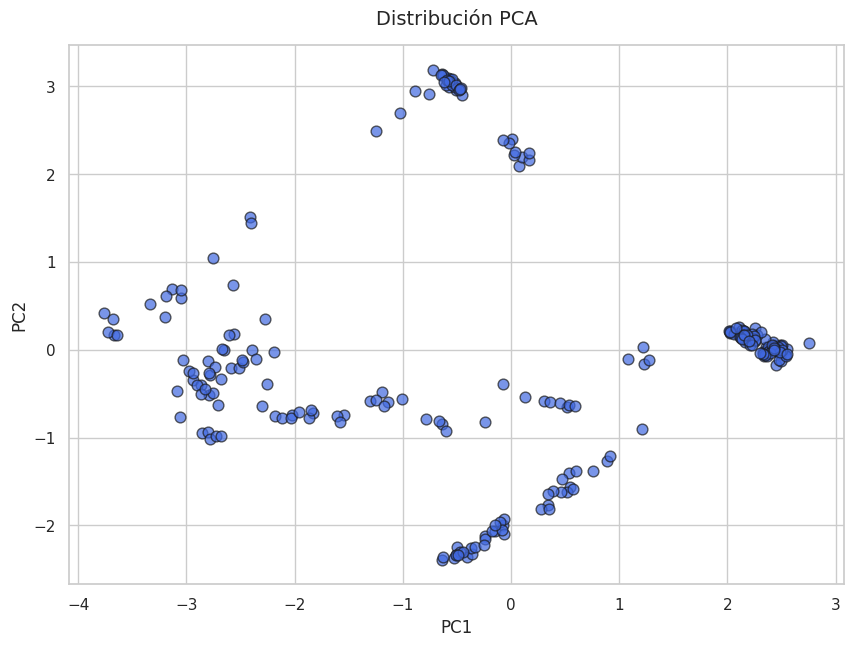

In [603]:
plt.figure(figsize=(10, 7))

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            alpha=0.7,
            edgecolors='k',
            s=60,
            color='royalblue')

plt.title('Distribución PCA', fontsize=14, pad=15)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.show()

## K-Means
Empezamos con el primer método de clustering, el K-Means, que busca particionar los datos en $k$ grupos (clusters) distintos, minimizando la distancia de cada punto al centroide de su grupo. Como K-Means requiere que le indiquemos el número de clusters a priori, utilizaremos dos métricas matemáticas para encontrar el valor óptimo de este hiperparámetro: el **Elbow Method (Inertia)** y el **Coeficiente Silhouette**.

In [604]:
# Lista para guardar la "Inertia" de cada modelo
inertias = []
# Lista para guardar el coeficiente Silhouette de cada modelo
silhouettes = []

# Probaremos desde 1 hasta 10 clusters
rango_k = range(1, 11) 

# Entrenamos un modelo K-Means para cada valor de k
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=100499978, n_init=10)
    preds = kmeans.fit_predict(X_reduced)
    
    # Inertias para Elbow method
    inertias.append(kmeans.inertia_)
    
    if k > 1:
        # Silhouette Score
        silhouette = silhouette_score(X_reduced, preds)
        silhouettes.append(silhouette)



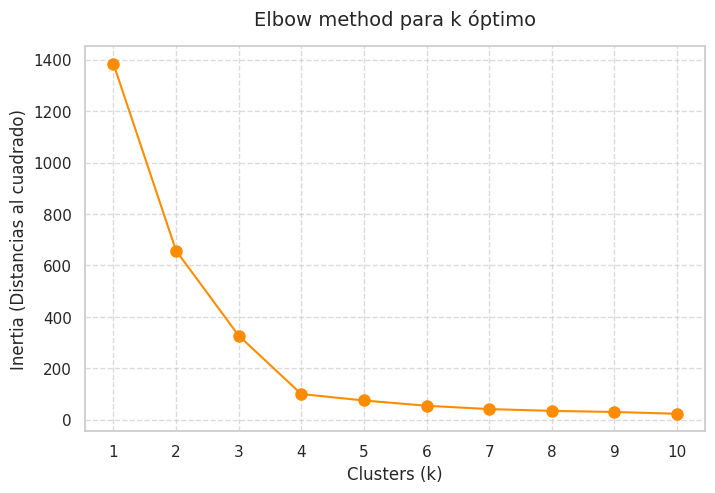

In [605]:
# Dibujamos la curva del Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inertias, marker='o', linestyle='-', color='darkorange', markersize=8)
plt.title('Elbow method para k óptimo', fontsize=14, pad=15)
plt.xlabel('Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Distancias al cuadrado)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

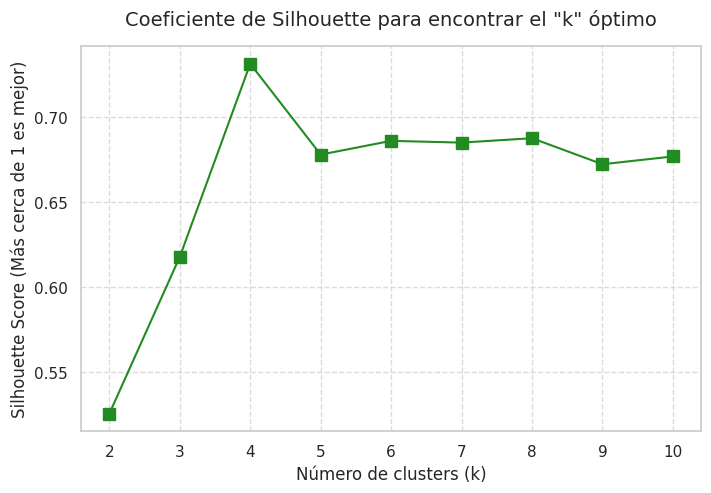

In [606]:
# Dibujamos el gráfico de Silhouette
rango_k_sil = range(2,11)
plt.figure(figsize=(8, 5))
plt.plot(rango_k_sil, silhouettes, marker='s', linestyle='-', color='forestgreen', markersize=8)
plt.title('Coeficiente de Silhouette para encontrar el "k" óptimo', fontsize=14, pad=15)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score (Más cerca de 1 es mejor)', fontsize=12)
plt.xticks(rango_k_sil)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análisis de métricas para la elección de $k$
Al observar los gráficos generados, podemos extraer las siguientes conclusiones puramente matemáticas:
*   **Elbow Method:** La inercia (suma de las distancias al cuadrado) cae de forma drástica hasta `k=4`, punto en el cual la gráfica forma un "codo" claro y comienza a aplanarse.

*   **Silhouette Score:** El coeficiente silhouette alcanza su pico máximo absoluto exactamente en `k=4`, lo que indica que con 4 clusters obtenemos los grupos más compactos y mejor separados entre sí.
Ambas métricas coinciden de forma unánime en que el valor óptimo es **$k=4$**.

Aunque los algoritmos nos sugieren agrupar los datos en 4 clusters, por la introducción y teoría astronómica de la práctica sabemos que en realidad existen **6 tipos de estrellas** en nuestro dataset. 

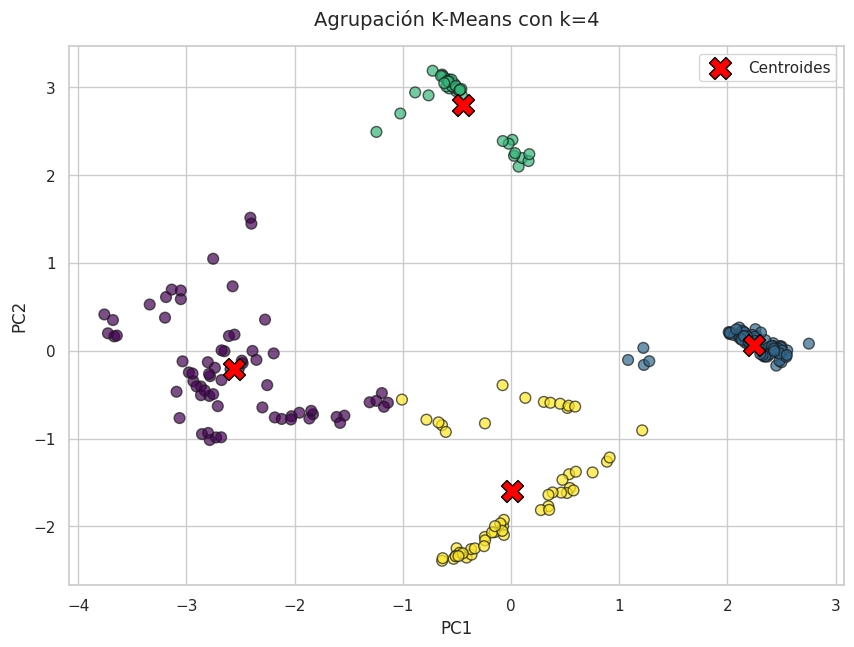

In [607]:
# Entrenamos el modelo definitivo con el k matemáticamente óptimo
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=100499978, n_init=10)

etiquetas_kmeans = kmeans_final.fit_predict(X_reduced)

centroides = kmeans_final.cluster_centers_

plt.figure(figsize=(10, 7))

# Pintamos las estrellas. El parámetro "c=etiquetas_kmeans" colorea cada punto según su grupo
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c=etiquetas_kmeans, cmap='viridis',
            alpha=0.7, edgecolors='k', s=60)

# Pintamos los centroides encima con una X
plt.scatter(centroides[:, 0], centroides[:, 1], 
            c='red', marker='X', s=250, edgecolors='black', label='Centroides')

plt.title(f'Agrupación K-Means con k={k_optimo}', fontsize=14, pad=15)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend()

plt.show()


Vamos a plantear el mismo modelo pero con 6 clusters que existen en realidad, a ver qué resultado obtenemos. Podemos observar que sigue 

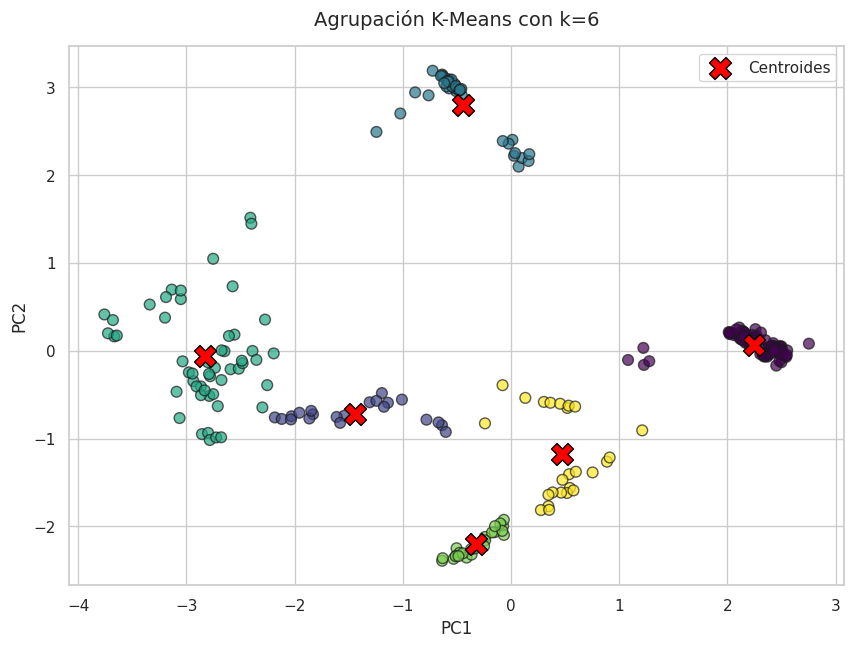

In [608]:
# Entrenamos el modelo definitivo con el k real
k_real = 6
kmeans_final = KMeans(n_clusters=k_real, random_state=100499978, n_init=10)

etiquetas_kmeans = kmeans_final.fit_predict(X_reduced)

centroides = kmeans_final.cluster_centers_

plt.figure(figsize=(10, 7))

# Pintamos las estrellas. El parámetro "c=etiquetas_kmeans" colorea cada punto según su grupo
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c=etiquetas_kmeans, cmap='viridis',
            alpha=0.7, edgecolors='k', s=60)

# Pintamos los centroides encima con una X
plt.scatter(centroides[:, 0], centroides[:, 1], 
            c='red', marker='X', s=250, edgecolors='black', label='Centroides')

plt.title(f'Agrupación K-Means con k={k_real}', fontsize=14, pad=15)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend()

plt.show()

## Hierarchical Clustering
A continuación, vamos a aplicar un modelo de clustering jerárquico para comprobar si la estructura de agrupamientos naturales coincide con la obtenida en K-Means.

Nuestra principal herramienta exploratoria será el **Dendrograma**, utilizando el método de enlace de Ward (que minimiza la varianza dentro de cada cluster al fusionarlos).

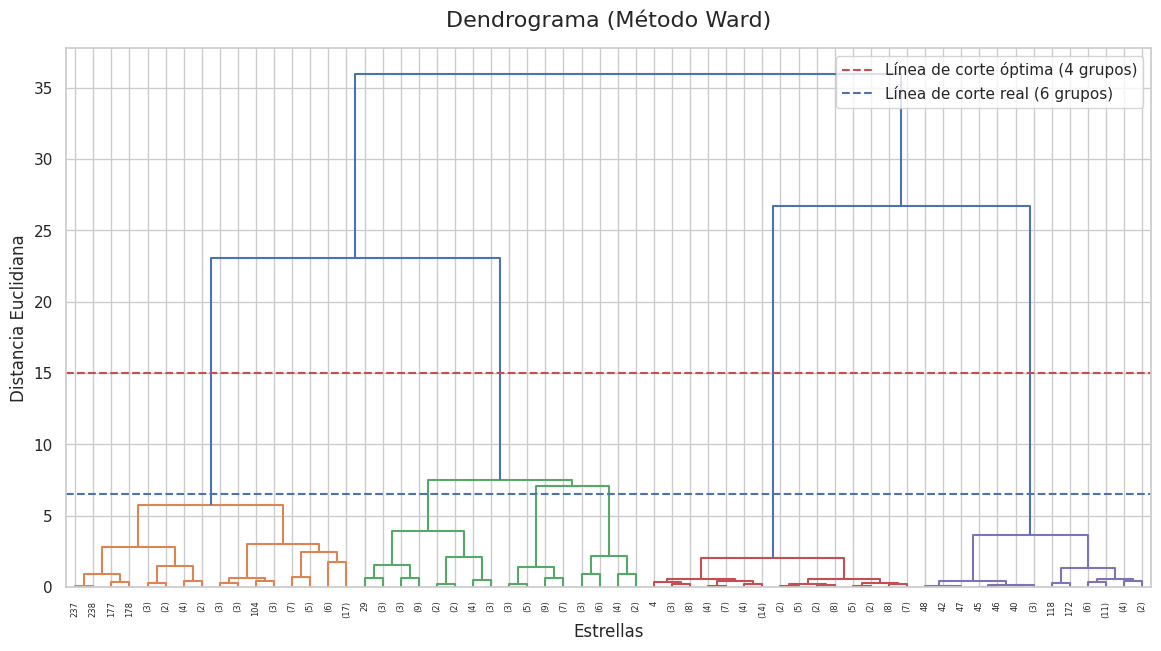

In [609]:
plt.figure(figsize=(14, 7))
plt.title('Dendrograma (Método Ward)', fontsize=16, pad=15)
plt.xlabel('Estrellas', fontsize=12)
plt.ylabel('Distancia Euclidiana', fontsize=12)

# Calculamos la matriz de enlace (linkage) usando 'ward'
matriz_enlace = sch.linkage(X_reduced, method='ward')

# Dibujamos el dendrograma
dendrograma = sch.dendrogram(matriz_enlace, truncate_mode='level', p=5, color_threshold=15)

plt.axhline(y=15, color='r', linestyle='--', label='Línea de corte óptima (4 grupos)')
plt.axhline(y=6.5, color='b', linestyle='--', label='Línea de corte real (6 grupos)')

plt.legend()

plt.show()


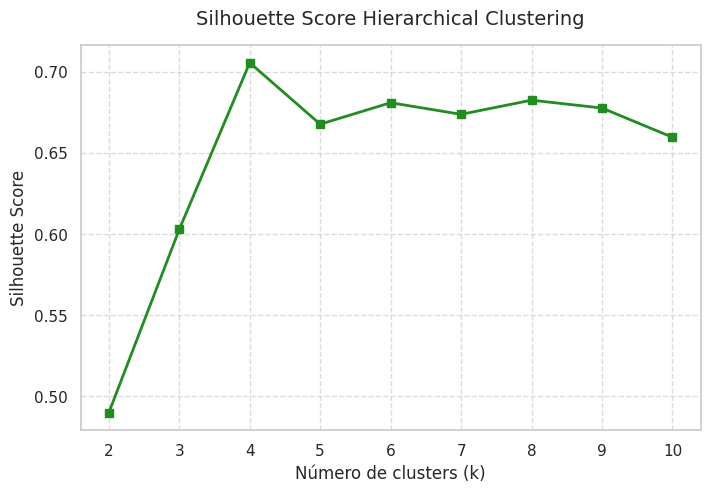

In [610]:

silhouettes_hierarchical = []
rango_k = range(2, 11) 
for k in rango_k:
    hierarchical_model = AgglomerativeClustering(n_clusters=k, linkage='ward', )
    preds = hierarchical_model.fit_predict(X_reduced)
    
    # Calculamos el Silhouette Score
    silhouette = silhouette_score(X_reduced, preds)
    silhouettes_hierarchical.append(silhouette)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, silhouettes_hierarchical, marker='s', color='forestgreen', linestyle='-', linewidth=2)
plt.title('Silhouette Score Hierarchical Clustering', fontsize=14, pad=15)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Interpretación del Dendrograma y Toma de Decisiones

Para construir este agrupamiento jerárquico hemos tomado dos decisiones fundamentales:

1. **Uso del método de enlace de Ward (`linkage='ward'`):** 
Hemos elegido el método de Ward porque, en cada paso de fusión, busca unir los dos grupos que generen el menor incremento posible en la varianza interna total. Esto favorece la creación de clusters muy densos y compactos. Su principal ventaja es que funciona con una filosofía idéntica a la del K-Means (minimizar la inercia), lo que nos permite comparar de forma justa los resultados de ambos algoritmos.

2. **Corte óptimo y Silhouette Score:** 
La elección de la altura para "cortar" el árbol y definir el número de clusters consiste en identificar el **salto de distancia más grande** en el dendrograma. Visualmente, buscamos el tramo vertical más largo que no esté interrumpido por ninguna otra fusión (ninguna línea horizontal cruzada). Trazando nuestra línea de corte $Y$ por el medio de ese tramo continuo más largo, garantizamos que estamos separando las estructuras de datos que son más inherentemente distintas entre sí. Vemos que este corte visual nos da **4 clusters**.

Para corroborar esta intuición, hemos calculado la métrica **Silhouette Score** aplicada a este modelo jerárquico. Al igual que ocurría con K-Means, la gráfica alcanza su pico máximo absoluto exactamente en **k=4**, confirmando matemáticamente que esta es la agrupación más sólida. Sin embargo, basándonos en la física del problema y nuestro conocimiento del dominio, sabemos que en realidad existen **6 tipos de estrellas**, por lo que resulta fundamental analizar también ese nivel de agrupación para ver qué clases estelares ha decidido fusionar el algoritmo.



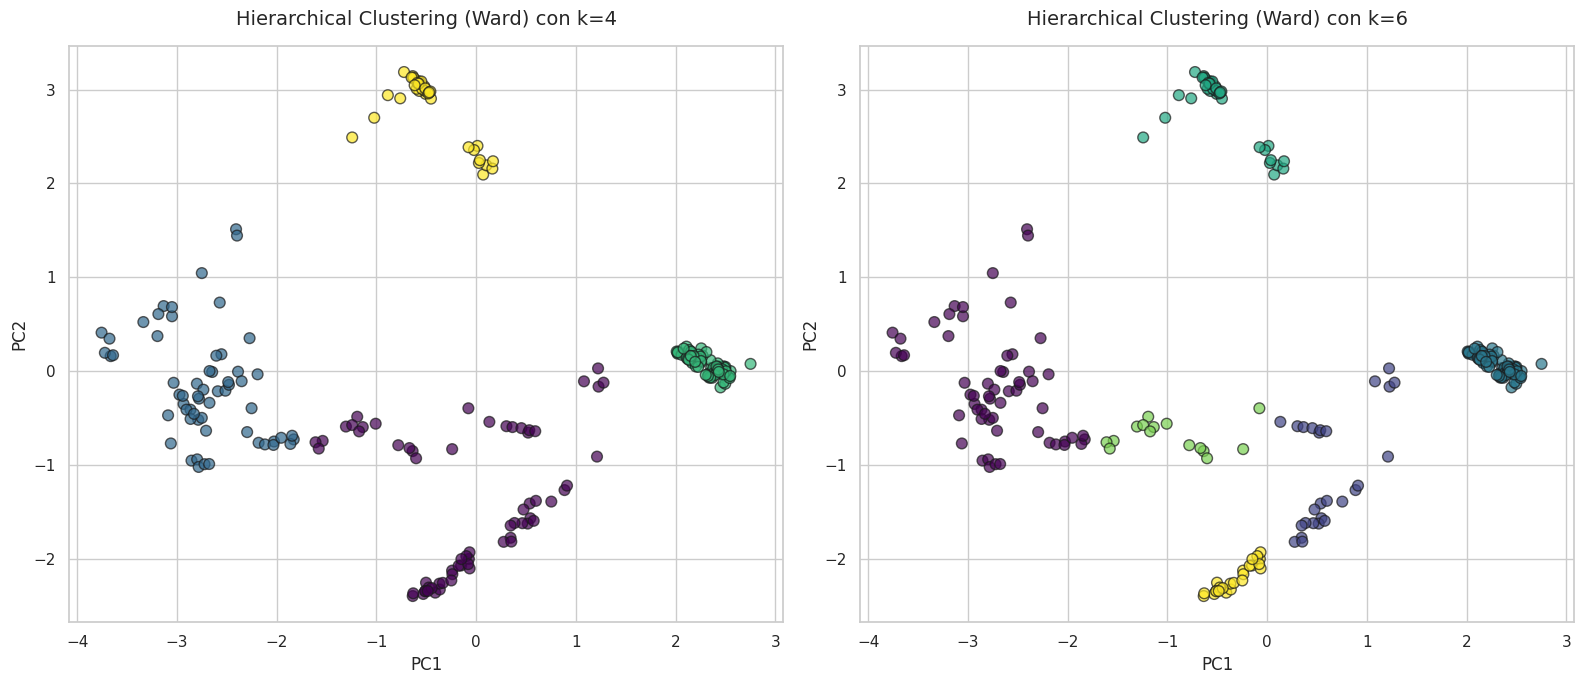

In [611]:
# Modelo matemáticamente óptimo (k=4)
jerarquico_k4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
etiquetas_k4 = jerarquico_k4.fit_predict(X_reduced)

# Modelo basado en conocimiento del dominio (k=6)
jerarquico_k6 = AgglomerativeClustering(n_clusters=6, linkage='ward')
etiquetas_k6 = jerarquico_k6.fit_predict(X_reduced)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(X_reduced[:, 0], X_reduced[:, 1], 
                c=etiquetas_k4, cmap='viridis', 
                alpha=0.7, edgecolors='k', s=60)
axes[0].set_title('Hierarchical Clustering (Ward) con k=4', fontsize=14, pad=15)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)

axes[1].scatter(X_reduced[:, 0], X_reduced[:, 1], 
                c=etiquetas_k6, cmap='viridis', 
                alpha=0.7, edgecolors='k', s=60)
axes[1].set_title('Hierarchical Clustering (Ward) con k=6', fontsize=14, pad=15)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)

plt.tight_layout()
plt.show()


Si lo comparamos con el K-Means obtenido anteriormente, vemos que el resultado es muy similar, aunque con diferencias sutiles.

Por ejemplo, para el caso de $k = 4$, los datos cuyo $PC1 \in [-2, 0]$ y $PC2 \in [-1, 0]$ en K-means son asignados al cluster de la izquierda mientras que en Hierarchical Clustering son asignados en el de la derecha.

## DBSCAN

In [612]:
# Rango de hiperparámetros a probar para DBSCAN
min_samples_values = [6, 7, 8, 9, 10, 11, 12, 13, 15, 17]
eps_values = [0.1, 0.3, 0.5, 0.6, 0.8, 1.0, 1.5]

best_dbcv = -np.inf
best_labels = None
best_min_samples = None
best_eps = None

# Búsqueda de los mejores hiperparámetros
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_reduced)
        
        # Necesitamos al menos 2 clusters para validar con DBCV y que el modelo no sea un cluster + ruido
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            # Evaluamos con la métrica DBCV
            score = dbcv_score(X_reduced, labels)
            if score > best_dbcv:
                best_dbcv = score
                best_labels = labels
                best_min_samples = min_samples
                best_eps = eps
                best_n_clusters = n_clusters
                best_n_noise = (labels == -1).sum()

print(f"Mejor configuración encontrada - min_samples: {best_min_samples} - eps: {best_eps} - n_clusters: {best_n_clusters}")
print(f"DBCV Score asociado: {best_dbcv:.4f}")


Mejor configuración encontrada - min_samples: 13 - eps: 0.6 - n_clusters: 4
DBCV Score asociado: 0.7004


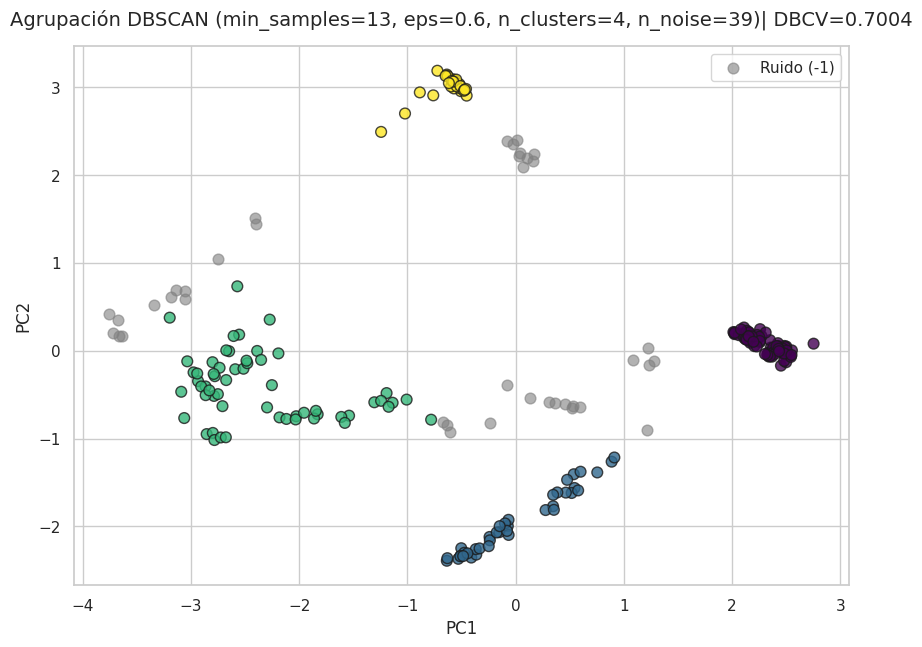

In [613]:
# Dibujamos el mejor modelo DBSCAN encontrado
plt.figure(figsize=(10, 7))

# Diferenciamos el ruido (label -1) del resto
ruido = (best_labels == -1)
clusters_mask = (best_labels != -1)

# Pintamos el ruido en color gris (puntos en lugar de cruces)
plt.scatter(X_reduced[ruido, 0], X_reduced[ruido, 1], 
            c='gray', alpha=0.6, label='Ruido (-1)', s=60)

# Pintamos los clusters usando el colormap validando a qué cluster pertenecen
plt.scatter(X_reduced[clusters_mask, 0], X_reduced[clusters_mask, 1], 
            c=best_labels[clusters_mask], cmap='viridis',
            alpha=0.8, edgecolors='k', s=60)

plt.title(f'Agrupación DBSCAN (min_samples={best_min_samples}, eps={best_eps}, n_clusters={best_n_clusters}, n_noise={best_n_noise})| DBCV={best_dbcv:.4f}', fontsize=14, pad=15)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend()
plt.show()

### Resultados de DBSCAN y DBCV

Al analizar los clústeres generados por DBSCAN, destacan diferencias notables respecto a K-Means y Hierarchical Clustering, explicadas fundamentalmente por el funcionamiento del algoritmo y la métrica de evaluación:

En primer lugar, DBSCAN es un algoritmo basado en **densidad**. A diferencia de K-Means, que asume que los grupos son esféricos y se basan en distancias a un centroide, DBSCAN simplemente busca áreas contiguas donde los puntos estén muy concentrados, esto como veremos a continuación, explica las diferencias en los clusters identificados.

En segundo lugar, para elegir los mejores hiperparámetros de este modelo no hemos utilizado *Silhouette*. El coeficiente Silhouette penaliza las geometrías complejas (como **arcos**) ya que evalúa la compacidad basada en distancias, asumiendo clústeres convexos/redondeados. 
Para solventarlo, se ha empleado la métrica **DBCV (Density-Based Clustering Validation)**, que evalúa exclusivamente modelos basados en densidad. DBCV compara la densidad mínima interna dentro de un clúster con la densidad del espacio que lo separa de los clústeres vecinos. El valor asociado a la mejor solución tiene un valor de 0,7004.

En terdecer lugar, a diferencia de modelos particionales que asocian cada estrella a un grupo forzosamente independientemente de lo lejos que esté (arrastrando y devaluando la posición del centroide), DBSCAN aísla los puntos en regiones subdensas y los marca directamente como **ruido** (puntos grises en nuestra gráfica). En nuestro caso, hay muchos puntos grises marcados como ruido (39), lo cual nos puede indicar que los grupos que detecta probablemente sean muy certeros, pero a cambio deja muchos puntos sin marcar.

### Comparación: DBSCAN vs Algoritmos Clustering Tradicionales

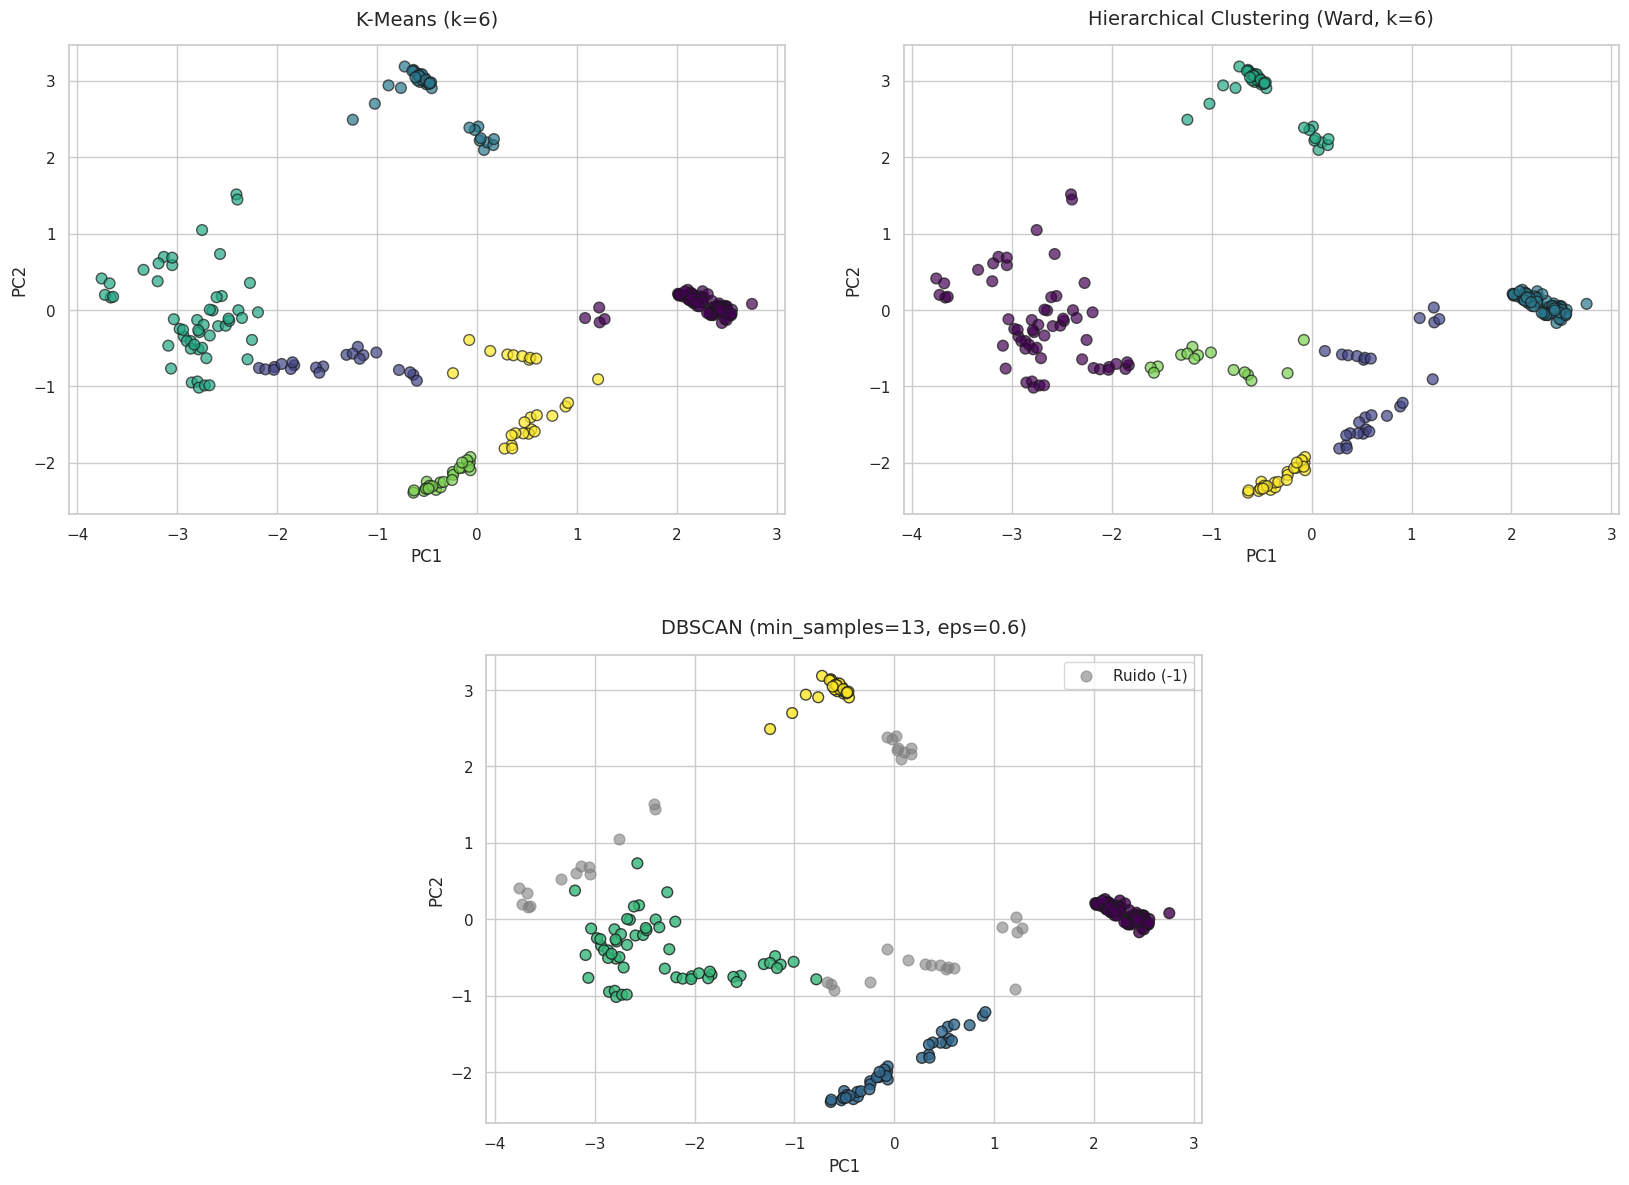

In [614]:
# Comparativa final de los 3 modelos clave (2 arriba, 1 abajo con el mismo tamaño)
fig = plt.figure(figsize=(20, 14))

# Usamos GridSpec para poder centrar la gráfica de abajo manteniendo el mismo tamaño
grid = plt.GridSpec(2, 4, wspace=0.4, hspace=0.3)

# 1. K-Means (k=6) -> Ocupa las columnas 0 y 1 de la fila 0
ax1 = fig.add_subplot(grid[0, 0:2])
ax1.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c=etiquetas_kmeans, cmap='viridis', 
            alpha=0.7, edgecolors='k', s=60)
ax1.set_title('K-Means (k=6)', fontsize=14, pad=15)
ax1.set_xlabel('PC1', fontsize=12)
ax1.set_ylabel('PC2', fontsize=12)

# 2. Hierarchical Clustering (k=6) -> Ocupa las columnas 2 y 3 de la fila 0
ax2 = fig.add_subplot(grid[0, 2:4])
ax2.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c=etiquetas_k6, cmap='viridis', 
            alpha=0.7, edgecolors='k', s=60)
ax2.set_title('Hierarchical Clustering (Ward, k=6)', fontsize=14, pad=15)
ax2.set_xlabel('PC1', fontsize=12)
ax2.set_ylabel('PC2', fontsize=12)

# 3. DBSCAN (mejor configuración) -> Ocupa las columnas 1 y 2 de la fila 1 (Centrado)
ax3 = fig.add_subplot(grid[1, 1:3])
ruido = (best_labels == -1)
clusters_mask = (best_labels != -1)

# Pintamos el ruido
ax3.scatter(X_reduced[ruido, 0], X_reduced[ruido, 1], 
            c='gray', alpha=0.6, label='Ruido (-1)', s=60)
# Pintamos los clústeres
ax3.scatter(X_reduced[clusters_mask, 0], X_reduced[clusters_mask, 1], 
            c=best_labels[clusters_mask], cmap='viridis',
            alpha=0.8, edgecolors='k', s=60)

ax3.set_title(f'DBSCAN (min_samples={best_min_samples}, eps={best_eps})', fontsize=14, pad=15)
ax3.set_xlabel('PC1', fontsize=12)
ax3.set_ylabel('PC2', fontsize=12)
ax3.legend()

plt.show()

Al observar detenidamente la comparativa visual entre los algoritmos, podemos distinguir claramente cómo el enfoque basado en densidad de DBSCAN explica las grandes diferencias en las agrupaciones formadas, frente a la presunción paramétrica de K-Means y del modelo Jerárquico de Ward.

En la zona central de la distribución, donde $PC_1 \approx 0$, K-Means y la clusterización jerárquica identifican dos grupos distintos (uno situado hacia la izquierda y otro hacia la derecha). Este comportamiento se debe a su naturaleza y la tendencia a agrupar conformando grupos compactos y esféricos. En contrapartida, DBSCAN interpreta toda esa masa como un clúster a la izquierda y ruido a la derecha.

Por último, destaca especialmente la nube de puntos situada en el cuadrante inferior izquierdo (con $PC_1$ entre -3 y -1, y $PC_2$ entre -1 y 0). Por la misma tendencia a forzar clústeres globulares, K-Means y el método jerárquico parten este segmento en dos grupos. Sin embargo, DBSCAN percibe de nuevo un único clúster. Esta área representa quizás el caso más claro de beneficio espacial de DBSCAN, dado que los puntos forman una estructura alargada con un patrón geométrico de arco o "luna", aunque también uno de sus grandes contras, el hecho de dejar muchos puntos como ruido sin ser asignados a ningún clúster.

## Conclusiones

### Benchmark Real (Etiquetas Físicas)
![Etiquetas Fisicas](../assets/etiquetas_fisicas.png)

In [615]:
# Mapeos ordinales globales
color_map = {"Blue": 0, "Blue-White": 1, "White": 2, "Yellow-White": 3, "Yellow": 4, "Orange": 5, "Red": 6}
spectral_map = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}

# Creación del DataFrame basado en la tabla de la imagen (Benchmark Real)
# (Para rangos espectrales se ha calculado la media posicional, ej. K-M -> (5+6)/2 = 5.5)
data_benchmark = {
    "Clase": ["Enana roja", "Enana marrón", "Enana blanca", "Estrella en secuencia principal", "Super gigante", "Hiper gigante"],
    "Temperatura": [3000, 3300, 14000, 16000, 15000, 11000],
    "L": [7.0e-4, 5.5e-3, 2.5e-3, 3.2e4, 3.0e5, 3.0e5],
    "R": [1.0e-1, 3.5e-1, 1.0e-2, 4.4, 50.0, 1.4e3],
    "A_M": [17.5, 12.5, 12.6, -0.4, -6.4, -9.6],
    "Color": [6, 6, 2, 3, 3, 4],
    "Spectral_Class": [5.5, 6.0, 2.5, 3.5, 3.5, 3.5]
}

df_benchmark = pd.DataFrame(data_benchmark)
display(df_benchmark)

,Clase,Temperatura,L,R,A_M,Color,Spectral_Class
0,Enana roja,3000,0.0007,0.10,17.5,6,5.5
1,Enana marrón,3300,0.0055,0.35,12.5,6,6.0
2,Enana blanca,14000,0.0025,0.01,12.6,2,2.5
3,Estrella en secuencia principal,16000,32000.0000,4.40,-0.4,3,3.5
4,Super gigante,15000,300000.0000,50.00,-6.4,3,3.5
5,Hiper gigante,11000,300000.0000,1400.00,-9.6,4,3.5


### Algoritmo de Elección

### Metodología de Evaluación: El Problema de Asignación y el Algoritmo Húngaro

Uno de los principales retos de esta práctica es que los algoritmos devuelven etiquetas numéricas arbitrarias que no tienen significado físico como tal. Para evaluar objetivamente qué tan bien ha capturado nuestro modelo la realidad, queríamos emparejar nuestros clústeres generados con las **clases estelares teóricas (Benchmark Real)**.

Realizar este emparejamiento de forma manual provocaría bastantes errores y a menudo lleva a emparejamientos subóptimos (obviando el hecho de que no somos astrónomos profesionales). Para evitarlo, hemos tratado esta evaluación como un **Problema de Asignación Lineal**, resolviéndolo mediante el **Algoritmo Húngaro** (`linear_sum_assignment` de la librería `scipy`).

El proceso diseñado es el siguiente:
1. **Extracción de Perfiles (Mediana Global):** Se calcula la mediana de todas las características físicas para cada clúster encontrado por el modelo, obteniendo su "perfil estelar" representativo.

2. **Escalado Dimensional (`MinMaxScaler`):** Dado que magnitudes como el Radio ($R$) o la Temperatura operan en escalas radicalmente distintas, se combinan los perfiles teóricos y los empíricos y se escalan entre 0 y 1 para que todas las características tengan el mismo peso en la evaluación.

3. **Matriz de Costes:** Se calcula una matriz matemática de $N \times N$ (donde $N=6$). Cada celda representa el "coste" (Distancia Euclidiana) de emparejar un clúster determinado con una clase estelar teórica concreta.

4. **Optimización Global (Algoritmo Húngaro):** El algoritmo busca en la matriz de costes la combinación 1-a-1. Encuentra la asignación única en la que la suma total de las distancias de todas las parejas sea la **mínima posible**.

5. **Aplicación de penalizaciones:** En caso de que haya modelos (como DBSCAN), que no puedes elegir el número de clústers, se aplicará una penalización en caso de que detecte menos clústers de los que en realidad hay (en nuestro caso hemos decidido que la penalización sea de 1, un valor más grande que las distancias que generan, pero lo suficientemente pequeño para detectar un algoritmo que aunque no acierte el número de clústers, sea certero en los que sí encuentra).

Con este proceso intentamos eliminar nuestra subjetividad a la hora de asignar tipos de estrellas a cada clúster. Además, nos devuelve una métrica global objetiva: el **"Total Cost"**. Este valor nos permitirá comparar directamente el rendimiento cualitativo de K-Means, el Clustering Jerárquico y DBSCAN frente al estándar astronómico real. Cuanto menor sea el coste, más preciso y fiel a la astrofísica real es el modelo.


In [616]:
def evaluate_clustering_hungarian(df_centroids, df_theoretical):
    """
    Empareja los centroides con las clases estelares teóricas minimizando el coste (Error Euclidiano global).
    """
    # Prepararamos los datos
    clases_nombres = df_theoretical['Clase'].values
    
    # Renombramos 'Temperatura' para cuadrar con las columnas de los centroides
    df_teo_num = df_theoretical.rename(columns={"Temperatura": "Temperature"})
    cols_features = ['Temperature', 'L', 'R', 'A_M', 'Color', 'Spectral_Class']
    
    # Extraemos sólo las features numéricas
    df_teo_num = df_teo_num[cols_features].copy()
    df_cent_num = df_centroids[cols_features].copy()
    
    # Escalado (MinMax) combinando los datos temporalmente
    combined_df = pd.concat([df_teo_num, df_cent_num], ignore_index=True)
    scaler = MinMaxScaler()
    combined_scaled = scaler.fit_transform(combined_df)
    
    # Separar datos tras el escalado global conservando su orden
    n_teo = len(df_teo_num)
    teo_scaled = combined_scaled[:n_teo]  # Benchmark
    cent_scaled = combined_scaled[n_teo:] # Centroides
    
    # Matriz de costes (Distancia Euclidiana)
    # Filas = Clusters de los algoritmos (n_clusters)
    # Columnas = Clases teóricas (n_clases)
    cost_matrix = cdist(cent_scaled, teo_scaled, metric='euclidean')
    
    # Algoritmo Húngaro linear sum assignment
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Calcular el error total global sumando las asignaciones óptimas
    base_cost = cost_matrix[row_ind, col_ind].sum()
    
    n_clases_reales = len(df_theoretical)
    n_clases_asignadas = len(col_ind)
    clases_faltantes = n_clases_reales - n_clases_asignadas
    
    # Castigamos cada clase teórica que se ha quedado "huérfana"
    PENALTY_PER_MISSING = 1.0 
    penalty_cost = clases_faltantes * PENALTY_PER_MISSING
    
    total_cost = base_cost + penalty_cost    
    # Recuperar nombres y formatear resultados
    mapping = []
    for r, c in zip(row_ind, col_ind):
        cluster_id = df_centroids.index[r]
        clase_asignada = clases_nombres[c]
        error = cost_matrix[r, c]
        mapping.append({
            "Cluster": cluster_id,
            "Clase Asignada (Real)": clase_asignada,
            "Error (Distancia)": error
        })
        
    return pd.DataFrame(mapping).set_index("Cluster"), total_cost

### K-Means

In [617]:
# Limpiamos los colores del dataset original para que coincidan con las categorías unificadas
df_kmeans = process_color(df)

# Aplicamos mapeo ordinal
df_kmeans['Color'] = df_kmeans['Color'].map(color_map)
df_kmeans['Spectral_Class'] = df_kmeans['Spectral_Class'].map(spectral_map)

# Añadimos las etiquetas del modelo K-Means con k=6
df_kmeans['Cluster'] = etiquetas_kmeans

# Al ser todo numérico, agrupamos y calculamos mediana global
combined_table_k = df_kmeans.groupby('Cluster').median()

print("Perfil físico de cada clúster (Mediana global):")
display(combined_table_k)

Perfil físico de cada clúster (Mediana global):


,Temperature,L,R,A_M,Color,Spectral_Class
Cluster,,,,,,
0,3186.0,0.000968,0.1605,14.783,6.0,6.0
1,15276.0,1092.000000,5.9920,-2.300,1.0,1.0
2,3602.5,200000.000000,1302.0000,-9.200,6.0,6.0
3,23047.5,247610.000000,65.0000,-6.345,0.0,0.0
4,16645.0,0.001145,0.0105,11.775,0.0,1.0
5,7740.0,0.000490,0.0120,12.890,3.0,3.0


In [618]:
best_df_k, total_cost_k = evaluate_clustering_hungarian(combined_table_k, df_benchmark)
print(f"Total cost: {total_cost_k}")
display(best_df_k)

Total cost: 3.401956636711259


,Clase Asignada (Real),Error (Distancia)
Cluster,,
0,Enana marrón,0.084435
1,Estrella en secuencia principal,0.549143
2,Hiper gigante,0.732879
3,Super gigante,0.884326
4,Enana blanca,0.438115
5,Enana roja,0.713058


### Hierarchical Clustering

In [619]:
# Limpiamos los colores del dataset original para que coincidan con las categorías unificadas
df_hierarchical = process_color(df)

# Aplicamos mapeo ordinal
df_hierarchical['Color'] = df_hierarchical['Color'].map(color_map)
df_hierarchical['Spectral_Class'] = df_hierarchical['Spectral_Class'].map(spectral_map)

# Añadimos las etiquetas del modelo Hierarchical con k=6 (calculado previamente como etiquetas_k6)
df_hierarchical['Cluster'] = etiquetas_k6

# Al ser todo numérico, agrupamos y calculamos mediana global
combined_table_h = df_hierarchical.groupby('Cluster').median()

print("Perfil físico de cada clúster (Mediana global) - Hierarchical Clustering:")
display(combined_table_h)

Perfil físico de cada clúster (Mediana global) - Hierarchical Clustering:


,Temperature,L,R,A_M,Color,Spectral_Class
Cluster,,,,,,
0,23047.5,239500.000000,51.50000,-6.235,0.0,0.0
1,7700.0,0.000500,0.01234,12.590,3.0,3.0
2,3154.0,0.000915,0.15710,15.495,6.0,6.0
3,3602.5,200000.000000,1302.00000,-9.200,6.0,6.0
4,11250.0,672.000000,5.68000,-0.120,1.0,2.0
5,16645.0,0.001145,0.01050,11.775,0.0,1.0


In [620]:
best_df_h, total_cost_h = evaluate_clustering_hungarian(combined_table_h, df_benchmark)
print(f"Total cost: {total_cost_h}")
display(best_df_h)

Total cost: 3.377563676460873


,Clase Asignada (Real),Error (Distancia)
Cluster,,
0,Super gigante,0.890014
1,Enana roja,0.715123
2,Enana marrón,0.110756
3,Hiper gigante,0.732879
4,Estrella en secuencia principal,0.490676
5,Enana blanca,0.438115


### DBSCAN

In [621]:
# Limpiamos los colores del dataset original para que coincidan con las categorías unificadas
df_dbscan = process_color(df)

# Aplicamos mapeo ordinal
df_dbscan['Color'] = df_dbscan['Color'].map(color_map)
df_dbscan['Spectral_Class'] = df_dbscan['Spectral_Class'].map(spectral_map)

# Añadimos las etiquetas del mejor modelo DBSCAN (calculadas previamente como best_labels)
df_dbscan['Cluster'] = best_labels

# Al ser todo numérico, agrupamos y calculamos mediana global
combined_table_d = df_dbscan.groupby('Cluster').median()

# Eliminamos fila de outliers
combined_table_d = combined_table_d.drop(index=-1, errors='ignore')

print("Perfil físico de cada clúster (Mediana global) - DBSCAN:")
print("Nota: El clúster -1 corresponde al ruido (outliers).")
display(combined_table_d)

Perfil físico de cada clúster (Mediana global) - DBSCAN:
Nota: El clúster -1 corresponde al ruido (outliers).


,Temperature,L,R,A_M,Color,Spectral_Class
Cluster,,,,,,
0,3154.0,0.000915,0.1571,15.495,6.0,6.0
1,13420.0,0.000780,0.0100,12.230,1.0,1.0
2,18734.0,198000.000000,24.0000,-5.830,0.0,0.0
3,3614.0,209000.000000,1349.0000,-10.700,6.0,6.0


In [622]:
best_df_d, total_cost_d = evaluate_clustering_hungarian(combined_table_d, df_benchmark)
print(f"Total cost: {total_cost_d}")
display(best_df_d)

Total cost: 4.057643062916387


,Clase Asignada (Real),Error (Distancia)
Cluster,,
0,Enana marrón,0.106610
1,Enana blanca,0.303000
2,Super gigante,0.873471
3,Hiper gigante,0.774562


### Veredicto final

In [41]:
# Preparamos los dataframes indexándolos por la Clase Real y renombrando la columna de error
df_k = best_df_k.reset_index().set_index("Clase Asignada (Real)")[["Error (Distancia)"]].rename(columns={"Error (Distancia)": "Error K-Means"})
df_h = best_df_h.reset_index().set_index("Clase Asignada (Real)")[["Error (Distancia)"]].rename(columns={"Error (Distancia)": "Error Jerárquico"})
df_d = best_df_d.reset_index().set_index("Clase Asignada (Real)")[["Error (Distancia)"]].rename(columns={"Error (Distancia)": "Error DBSCAN"})

# Concatenamos (join tipo outer por defecto) los 3 dataframes
df_comparativa = pd.concat([df_k, df_h, df_d], axis=1)

# Añadimos el coste total calculado previamente incluyendo penalizaciones
df_comparativa.loc['Coste Total (Con penalizaciones)'] = [total_cost_k, total_cost_h, total_cost_d]

print("Comparativa de Errores por Algoritmo y Clase Estelar:")
display(df_comparativa)

Comparativa de Errores por Algoritmo y Clase Estelar:


,Error K-Means,Error Jerárquico,Error DBSCAN
Clase Asignada (Real),,,
Enana marrón,0.084435,0.110756,0.106610
Estrella en secuencia principal,0.549143,0.490676,NaN
Hiper gigante,0.732879,0.732879,0.774562
Super gigante,0.884326,0.890014,0.873471
Enana blanca,0.438115,0.438115,0.303000
Enana roja,0.713058,0.715123,NaN
Coste Total (Con penalizaciones),3.401957,3.377564,4.057643


Tras evaluar de forma matemática los perfiles físicos de los clústeres frente al benchmark teórico astronómico (utilizando la asignación óptima del Algoritmo Húngaro), hemos obtenido los siguientes márgenes de error global:

*   **Clustering Jerárquico (Ward):** `3.37`
*   **K-Means:** `3.40`
*   **DBSCAN:** `4.05` (Base: 2.05 + Penalización: 2.00)

**Conclusión:**
El modelo ganador matemáticamente para la tarea de aislar las 6 clases estelares es el **Clustering Jerárquico (Ward)**. Al presentar el menor error global, demuestra ser el algoritmo que mejor logra forzar la segmentación del espacio de datos para que coincida con las divisiones teóricas que hemos calculado, superando ligeramente a K-Means.

Sin embargo, aunque DBSCAN presenta el "Total Cost" más alto, si analizamos un poco podemos observar que al identificar solo 4 clústeres, sufrió una penalización de $+2.0$. Su error base para esos 4 grupos fue bastante bajo (2.05). Esto nos indica que DBSCAN es más preciso, pero no se arriesga a segmentar artificialmente el continuo de estrellas, fusionando clases que K-Means o el Jerárquico sí fuerzan a separar geométricamente, sumando el hecho de que no estamos contando para su evaluación los puntos de ruido (que penalizarían bastante). 

De hecho, DBSCAN es **muy superior clasificando Enanas Blancas** (Error $\approx 0.3$) y conjuntamente los **extremos** de la taxonomía de estrellas aunque a la hora de clasificar estrellas hiper gigantes (Error $\approx 0.77$) **es peor** que los otros dos algoritmos (Error $\approx 0.73$)

Por lo tanto, a no ser que únicamente queramos identificar Enanas Blancas con mucha exactitud nos quedamos antes con cualquiera de los dos modelos.

K-Means y Clusteing Jerárquico están bastante parejos. **Conjuntamente** Clustering Jerárquico es superior a K-Means por lo que ante una necesidad de identificar con solvencia todos el espectro de estrellas esta sería nuestra mejor opción. Si bien, K-Means identifica sobre todo **Enanas Marrones y Estrellas Super Gigantes** mejor que Clustering Jerárquico, y por ende, **si priorizamos** la identificación de estas categorías nos quedaríamos con K-Means. Por el contrario, Clustering Jerárquico identifica mejor las **Estrellas en Secuencia Principal**.

En resumen, a falta de tener ciertas prioridades de investigación de unas estrellas sobre otras nos quedamos para una mejor identificación global de todo el espectro con **Clustering Jerárquico**.
